# Generar trajectòries

Algorisme de l'article [Spectral-clustering approach to Lagrangian vortex detection](https://arxiv.org/pdf/1506.02258) a partir de trajectòries del sistema dinàmic donat 
pel següent sistema d'EDOs, on $f(t)=sin(t)$.
$$x'=y + \epsilon f(t)$$ $$y'=x-x^3$$

In [161]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.integrate import solve_ivp
from typing import Tuple, Iterable
from datetime import datetime
np.set_printoptions(precision=3, suppress=True)

In [162]:
def edo_duffing_soroll(t, z, random=1, epsilon=0.05, funcio_soroll=np.sin):
    """Paràmetres:
        t: temps
        z: posició al pla R^2
        random: nombre real aleatori entre 0 i 2
        epsilon: paràmetre entre 0 i 1 que regula el soroll
        funcio_soroll: pertorbació que depèn del temps
    Retorna el camp vectorial del sistema d'EDOs x'=y+epsilon*random*f(t); y'=x-x^3.
    """
    x, y = z
    soroll = epsilon *  random * funcio_soroll(t)
    camp_vectorial = [y + soroll, x - x**3]
    return np.array(camp_vectorial)

##### Paràmetres

In [163]:
# epsilon = 0.05
epsilon = 0
funcio_soroll = np.sin
dimensio = 2
t_span = (0, 30)
t_steps = 300
t_valors = np.linspace(t_span[0], t_span[1], t_steps)
x_min, x_max = (-1.5, 1.5)
y_min, y_max = (-0.8, 0.8)
step_size_initial_condition_mesh = 0.1

In [164]:
# Gràfica
radi = 0.3
centre_esquerre = (-1, 0)
centre_dret = (1, 0)
centre_nord = (0, 1)
centre_sud = (0, -1)
resolucio_grafica = 2000

### Gràfiques

In [165]:
def grafica_circumferencia(centre: Tuple[float, float],
                           radi: float, 
                           nom_regio:str,
                           resolucio: int) -> None:
    theta = np.linspace(0, 2*np.pi, resolucio)
    a, b = centre
    xx = radi*np.cos(theta) + a
    yy = radi*np.sin(theta)
    plt.plot(xx, yy + b, 'black')
    plt.plot(xx, - yy + b, 'black')
    plt.annotate(nom_regio, centre)

def grafica_regio(nom_regio: str, radi: float, centres: list[Tuple[float, float]], resolucio: int) -> None:
    for centre in centres:
        grafica_circumferencia(centre, radi, nom_regio, resolucio)

def grafica_regions_A_B(radi: float, resolucio: int) -> None:
    grafica_regio('A', radi, [centre_esquerre, centre_dret], resolucio)
    grafica_regio('B', radi, [centre_nord, centre_sud], resolucio)

In [166]:
def grafica_trajectories(trajectories: np.ndarray,
                         dibuixa_regions: bool = False,
                         desa_pdf: bool = False, 
                         radi: float = radi, 
                         resolucio: int = resolucio_grafica
                         ) -> None:
    if dibuixa_regions: grafica_regions_A_B(radi, resolucio)
    for trajectoria in trajectories:
        coordenades_x = trajectoria[:,0]
        coordenades_y = trajectoria[:,1]
        plt.plot(coordenades_x, coordenades_y)
    for trajectoria in trajectories:
        coordenades_x = trajectoria[:,0]
        coordenades_y = trajectoria[:,1]
        pos_inicial = (coordenades_x[0], coordenades_y[0])
        inici_string = f'Inici = ({pos_inicial[0]:.2f}, {pos_inicial[1]:.2f})'
        plt.plot(pos_inicial[0], pos_inicial[1], '-o', label=inici_string, color='grey')
        pos_final = (coordenades_x[-1], coordenades_y[-1])
        final_string = f'Final = ({pos_final[0]:.2f}, {pos_final[1]:.2f})'
        plt.plot(pos_final[0], pos_final[1], '-o', label=final_string, color='red')
    plt.xlabel('x')
    plt.ylabel('y') 
    # plt.legend(); 
    plt.grid()
    plt.gca().set_aspect('equal', adjustable='box')
    # plt.gca().set_xlim(-10, 10)
    if desa_pdf: plt.savefig('edo.pdf')
    plt.show()

In [167]:
def grafica_punts(punts: Iterable, dibuixa_regions=False, radi=radi, resolucio=resolucio_grafica) -> None:
    """punts: conjunt de punts a R^2. Exemple: [[0,1], [0.5,1], [1,1]]"""
    if dibuixa_regions:
        grafica_regions_A_B(radi, resolucio)
    for punt in punts:
        plt.plot(punt[0], punt[1], 'o', markersize=8, color="grey")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Condicions inicials')
    plt.grid()
    plt.gca().set_aspect('equal')
    plt.show()

### 1. Generar $n$ posicions inicials aleatòries

In [168]:
def generar_malla_condicions_inicials(step_size: float) -> Tuple[np.ndarray, int]:
    x = np.arange(x_min, x_max + step_size, step_size)
    y = np.arange(y_min, y_max + step_size, step_size)
    num_x = len(x)
    num_y = len(y)
    num_condicions_inicals = num_x * num_y
    malla = np.zeros((num_condicions_inicals, dimensio))
    for i in range(len(x)):
        for j in range(len(y)):
            malla[i * num_y + j] = [x[i], y[j]]
    return malla, num_condicions_inicals

Nombre de trajectories = 527


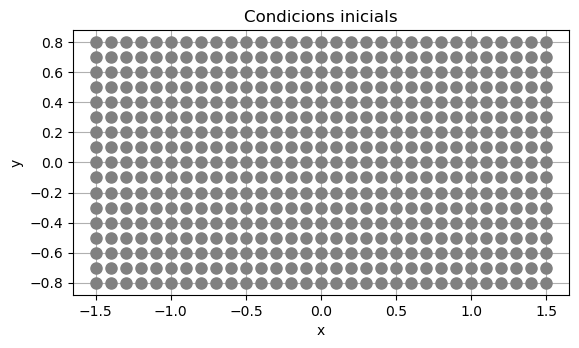

In [169]:
condicions_inicials, num_trajectories = generar_malla_condicions_inicials(step_size_initial_condition_mesh)
print(f"Nombre de trajectories = {num_trajectories}")
grafica_punts(condicions_inicials, dibuixa_regions=False)

### 2. Generar $n$ trajectòries, una per a cada posició inicial

In [170]:
def generar_trajectories(edo,
                         condicions_inicials: np.ndarray,
                         t_span: Tuple[float, float],
                         t_valors: np.ndarray) -> np.ndarray:
    """
    Paràmetres:
        edo: funció que representa el camp vectorial d'una EDO
        num_trajectories: nombre de trajectòries a generar
        condicions_inicials: llista que conté condicions inicials [x0,y0]
        t_valors: np.array[float], conté els instants de temps on avaluem l'EDO
    
    Cada trajectòria és la solució de l'EDO avaluada en els instants de temps indicats.
    """
    trajectories = np.zeros((num_trajectories, t_steps, dimensio))
    valor_random = np.random.uniform(0, 2)
    for i, ci in enumerate(condicions_inicials):
        # valor_random = np.random.uniform(0, 2)
        arguments_extra = (valor_random, epsilon, funcio_soroll)
        sol = solve_ivp(edo, t_span, ci, t_eval=t_valors, args=arguments_extra)
        trajectoria = np.vstack([sol.y[0], sol.y[1]])
        trajectoria = trajectoria.T
        trajectories[i] = trajectoria
    return trajectories

(Num trajectories, t_steps, dimensio) = (527, 300, 2)


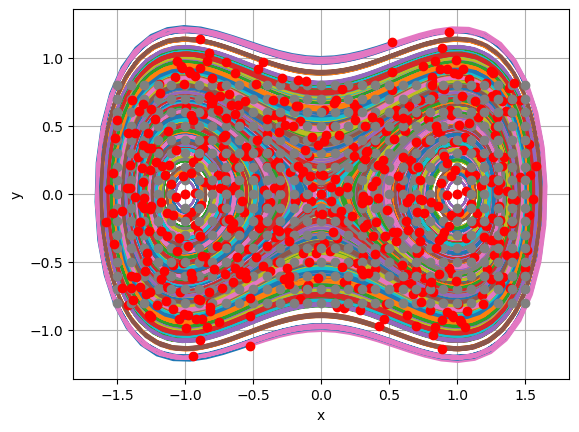

In [171]:
trajectories = generar_trajectories(edo_duffing_soroll, condicions_inicials, t_span, t_valors)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)
grafica_trajectories(trajectories, dibuixa_regions=False)

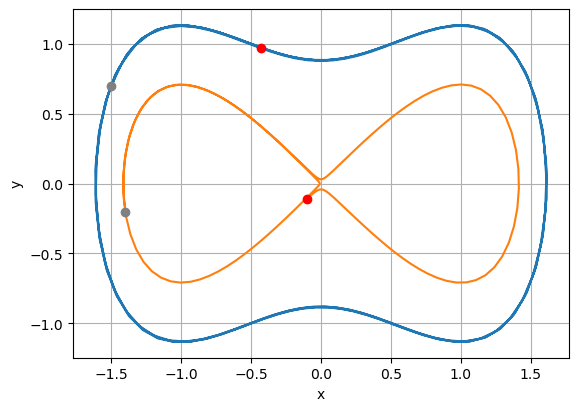

In [172]:
exemples = np.array((trajectories[15], trajectories[23]))
grafica_trajectories(exemples)

### 3. Calcular distància $r_{ij}$ entre trajectòries

In [173]:
def calcula_distancia(trajectoria_i: np.ndarray, trajectoria_j: np.ndarray, t_valors: np.ndarray) -> float:
    """Requisit: el pas de temps ha de ser constant"""
    distancia = 0
    num_t_steps = len(t_valors)
    dist_k_old = np.linalg.norm(trajectoria_i[0] - trajectoria_j[0]) # Norma euclidia de vectors en R^2
    for k in range(1, num_t_steps):
        dist_k_new = np.linalg.norm(trajectoria_i[k] - trajectoria_j[k])
        distancia += (dist_k_old + dist_k_new)
        dist_k_old = dist_k_new
    t_span_size = t_valors[-1] - t_valors[0]
    t_step_size = t_valors[1] - t_valors[0]
    return t_step_size * distancia / (2 * t_span_size)

In [174]:
def calcula_pes(i: int, j: int, trajectories: np.ndarray, t_valors: np.ndarray) -> float:
    pes_ij = 1 / calcula_distancia(trajectories[i], trajectories[j], t_valors)
    return pes_ij

### 4. Crear graf $G = (V, E, W)$ i matriu de similaritat $W$

Els vèrtexs són cadascuna de les $n$ trajectòries: $V=\{v_1,...,v_n\}$.

Cada aresta $e_{ij}\in E\subseteq V\times V$ està associada al pes $w_{ij}\in W\in\R^{n\times n}$, on $W$ és la matriu de similaritat i $w_{ij} = 1/r_{ij}$. Cada pes representa quant de properes són dues trajectòries ($0 \rightarrow$ poc, i $\infty \rightarrow$ molt).

In [190]:
def calcula_matriu_pesos_old(trajectories: np.ndarray, t_valors: np.ndarray) -> np.ndarray:
    num_trajectories = len(trajectories)
    matriu_pesos = np.zeros((num_trajectories, num_trajectories))
    for i in range(num_trajectories):
        for j in range(i + 1, num_trajectories):
            pes_ij = calcula_pes(i, j, trajectories, t_valors)
            matriu_pesos[i][j] = pes_ij
            matriu_pesos[j][i] = pes_ij
    return matriu_pesos

In [191]:
def calcula_matriu_pesos(trajectories: np.ndarray, t_valors: np.ndarray):# -> Tuple[np.ndarray, np.float64, np.float64]:
    num_trajectories = trajectories.shape[0]
    t_span_size = t_valors[-1] - t_valors[0]
    matriu_pesos = np.zeros((num_trajectories, num_trajectories))
    pes_max = - np.inf
    pes_min = np.inf
    for i in range(num_trajectories - 1):
        # Calcula la diferència de la trajectòria 'i' amb totes les 'j > i' alhora
        # trajectories[i] té forma (T, 2), trajectories[i+1:] té forma (N-i-1, T, 2)
        diff = trajectories[i] - trajectories[i+1:]
        # Calcula la norma euclidiana per a cada punt temporal: forma (N-i-1, T)
        norms = np.linalg.norm(diff, axis=2)
        # Integra les distàncies usant la regla del trapezi: forma (N-i-1,)
        distancies = sp.integrate.trapezoid(norms, x=t_valors, axis=1) / t_span_size
        # Calcula el pes i omple la matriu simètricament
        pesos = 1.0 / distancies
        matriu_pesos[i, i+1:] = pesos
        matriu_pesos[i+1:, i] = pesos
        pes_max = max(pes_max, np.max(pesos))
        pes_min = min(pes_min, np.min(pesos))
    return matriu_pesos, pes_max, pes_min

In [192]:
def sparcify(matriu: np.ndarray, tol: float) -> np.ndarray:
    """Retorna una matriu on els elements més petits que la tolerància es tornen zero.
    Requisit: la matriu ha de ser simètrica."""
    matriu_esparsa = np.copy(matriu)
    if tol == 0:
        return matriu_esparsa
    for i in range(len(trajectories)):
        for j in range(i+1, len(trajectories)):
            if matriu_esparsa[i][j] < tol:
                matriu_esparsa[i][j] = 0
                matriu_esparsa[j][i] = 0
    return matriu_esparsa

In [193]:
def calcula_matriu_similaritat(matriu_pesos: np.ndarray, tol: float, constant_diagonal: float) -> np.ndarray:
    """Retorna la matriu de similaritat, 
    on els elements més petits que la tolerància es tornen zero 
    i la diagonal s'omple amb el valor constant_diagonal."""
    matriu_similaritat = sparcify(matriu_pesos, tol)
    np.fill_diagonal(matriu_similaritat, constant_diagonal)
    return matriu_similaritat

### 4.1 Matriu de similaritat

In [218]:
matriu_pesos, pes_max, pes_min = calcula_matriu_pesos(trajectories, t_valors)
print(f"Dimensions de la matriu_pesos: {matriu_pesos.shape}")
print(f"Pes maxim: {pes_max}")
print(f"Pes minim: {pes_min}")
print(matriu_pesos)

Dimensions de la matriu_pesos: (527, 527)
Pes maxim: 35.09295114527891
Pes minim: 0.3518452970686857
[[0.    1.144 0.702 ... 0.458 0.383 0.352]
 [1.144 0.    1.264 ... 0.397 0.366 0.383]
 [0.702 1.264 0.    ... 0.386 0.397 0.458]
 ...
 [0.458 0.397 0.386 ... 0.    1.264 0.702]
 [0.383 0.366 0.397 ... 1.264 0.    1.144]
 [0.352 0.383 0.458 ... 0.702 1.144 0.   ]]


In [216]:
mean = float(np.sum(matriu_pesos) / (num_trajectories * (num_trajectories - 1)))
print(f"{mean = }")

mean = 0.9039655955573211


In [196]:
matriu_similaritat_W = calcula_matriu_similaritat(matriu_pesos, tol=0, constant_diagonal=10000000)

### 5. Calcular el grau

In [197]:
def calcula_grau(vertex: int, matriu_similaritat: np.ndarray) -> float:
    return sum(matriu_similaritat[vertex][j] for j in range(len(matriu_similaritat)))

In [198]:
def calcula_volum(vertexs: Iterable[int], matriu_similaritat: np.ndarray) -> np.ndarray:
    return np.diag([calcula_grau(vertex, matriu_similaritat) for vertex in vertexs])

In [199]:
def calcula_matriu_grau(matriu_similaritat: np.ndarray) -> np.ndarray:
    tots_els_vertexs = range(len(matriu_similaritat))
    return calcula_volum(tots_els_vertexs, matriu_similaritat)

In [200]:
matriu_grau_D = calcula_matriu_grau(matriu_similaritat_W)
print(np.shape(matriu_grau_D))

(527, 527)


### 6. Fer que la matriu de similiaritat $W$ sigui _sparse_ usant $k$-nearest neighbors [opcional]

O bé quedarse només amb els pesos $w_{ij}$ més grans que una tolerància $\epsilon$. (Aquesta $\epsilon$ és diferent de l'$\epsilon$ de l'EDO). L'obectiu de tornar la matriu sparse és per reduir la memòria que ocupa i poder emmagatzemar-la.

#### Trobar la partició que satisfà _mincut_

In [201]:
def pes_del_tall(vertexs_A: Iterable[int], vertexs_B: Iterable[int]) -> float:
    return sum(matriu_similaritat_W[i][j] for i in vertexs_A for j in vertexs_B)

In [202]:
def exemple():
    meitatA = range(num_trajectories//2)
    meitatB = range(num_trajectories//2, num_trajectories)
    print(pes_del_tall(meitatA, meitatB))

### 7. Descomposició espectral: $Lu =\lambda Du \iff D^{-1}Lu=\lambda u$

In [203]:
def inverteix_matriu_diagonal(matriu: np.ndarray) -> np.ndarray:
    """Requisit: la matriu diagonal ha de ser invertible."""
    return np.diag(1/np.diag(matriu))

In [204]:
def matriu_per_calcular_vaps(matriu_grau_D: np.ndarray, matriu_similaritat_W: np.ndarray) -> np.ndarray:
    matriu_grau_D_inversa = inverteix_matriu_diagonal(matriu_grau_D)
    matriu_laplacia_L = matriu_grau_D - matriu_similaritat_W
    matriu_per_calcular_vaps = matriu_grau_D_inversa @ matriu_laplacia_L
    return matriu_per_calcular_vaps

In [205]:
matriu_per_calcular_vaps = matriu_per_calcular_vaps(matriu_grau_D, matriu_similaritat_W)
vaps, veps = np.linalg.eigh(matriu_per_calcular_vaps) # ja venen ordenats ascendentment
print("vaps =", vaps)
print("veps.shape =", veps.shape)

vaps = [-0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.

In [206]:
vaps = vaps[1:] # eliminem el VAP més petit perquè és zero
print(vaps)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

### 8. Estimació del nombre de clústers $k$ = argmin [max($g_i$)]

In [207]:
def diferencia_n_essima(vector: np.ndarray, index: int) -> float:
    return vector[index + 1] - vector[index]

In [208]:
vaps_diferencies = np.array([diferencia_n_essima(vaps, i) for i in range(len(vaps) - 1)])
print(vaps_diferencies)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [209]:
limit = 100 # no poden haver més de 100 clusters per les propietats del sistema dinàmic
num_clusters_k = 1 + np.argmax(vaps_diferencies[:limit]) # sumem 1 perquè abans hem tret el VAP zero
print("nombre de clusters =", num_clusters_k)

nombre de clusters = 4


### 9. $k$-means

In [210]:
matriu_veps_U = veps[:, :num_clusters_k]
num_clusters_total = num_clusters_k + 1 # el cluster afegit representa els estats incoherents
kmeans = KMeans(n_clusters=num_clusters_total, n_init=100)
labels = kmeans.fit_predict(matriu_veps_U)

c:\Users\vlope\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [211]:
colors = {
    0: '#E74C3C',  # Vermell
    1: '#2ECC71',  # Verd
    2: '#3498DB',  # Blau
    3: '#F1C40F'   # Groc
}

In [212]:
def grafica_clusters(condicions_inicials, labels, colors=colors):
    for cluster_id, hex_color in colors.items():
        indices = np.where(labels == cluster_id)
        if len(indices[0]) > 0:
            plt.scatter(condicions_inicials[indices, 0], condicions_inicials[indices, 1], c=hex_color, s=70, label=cluster_id)
    plt.title('Clusters')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend(title="Cluster", loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect('equal')
    timestamp = datetime.now().strftime("%Y-%m-%dT%H-%M-%S")
    filename = f"{timestamp}_clusters={num_clusters_total}_traj={num_trajectories}_t_steps={t_steps}_t_end={t_span[-1]}.pdf"
    plt.savefig(f"grafiques/{filename}")
    plt.show()

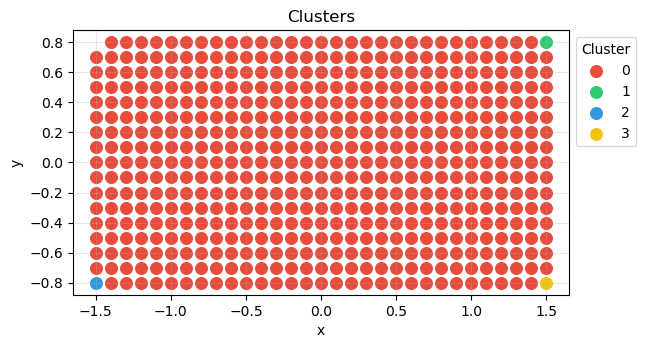

In [213]:
grafica_clusters(condicions_inicials, labels)